# Exercise 1

Import packages

In [3]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

In this exercise you should implement everything including the tests
(e.g. the chi-square and KS tests) yourself. I recommend that you
also code routines for histogrammes yourself to better control
limits, but this is not strictly needed. Later, when your code is
working you are free to use builtin functions.

###  1  

Write a program implementing a linear congruential generator
(LCG). Be sure that the program works correctly using only
integer representation.



In [4]:
#Function for Linear Congruential Generator
def LCG(x0, a, c, M, n):
    """
    x0:         seed
    a:          multiplier
    c:          increment
    M:          modulus
    n:          number of RNs sought
    """

    #List containing RNs
    RNs = [x0/M]

    #Set seed (first number)
    x_im1 = x0

    #Loop for generating n RNs (minus one, since we initialise with one value)
    for i in range(n-1):

        #Compute next number
        x_i = (a*x_im1+c) % M

        #Append normalised number to list
        RNs.append(x_i/M)

        #Update number
        x_im1 = x_i

    #Convert list to numpy array
    return np.array(RNs)

#### a) 
Generate 10.000 (pseudo-) random numbers and present these numbers in a histogramme (e.g. 10 classes).

In [5]:
#Seed
x0 = 3
#multiplier
a = 5
#increment
c = 1
#Modulus
M = 16
#Number of random numbers
n_RNs = 10000

#Create RNs
RNs = LCG(x0, a, c, M, n_RNs)
#print first numbers to verify with slide
print(RNs[:17]*M)

[ 3.  0.  1.  6. 15. 12. 13.  2. 11.  8.  9. 14.  7.  4.  5. 10.  3.]


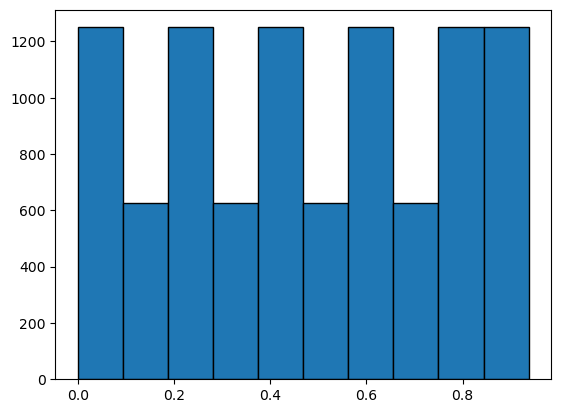

In [6]:
### Plotting
fig, axs = plt.subplots(1,1)

#Number of bins
n_bins=10

axs.hist(RNs, bins=n_bins, edgecolor='black')
plt.show()

#### (b) 
Evaluate the quality of the generator by graphical
descriptive statistics (histogrammes, scatter plots) and
statistical tests - χ2,Kolmogorov-Smirnov, run-tests
preferably but not necessarily all 3, and correlation test for
some h-values.


##### Histograms with different binning

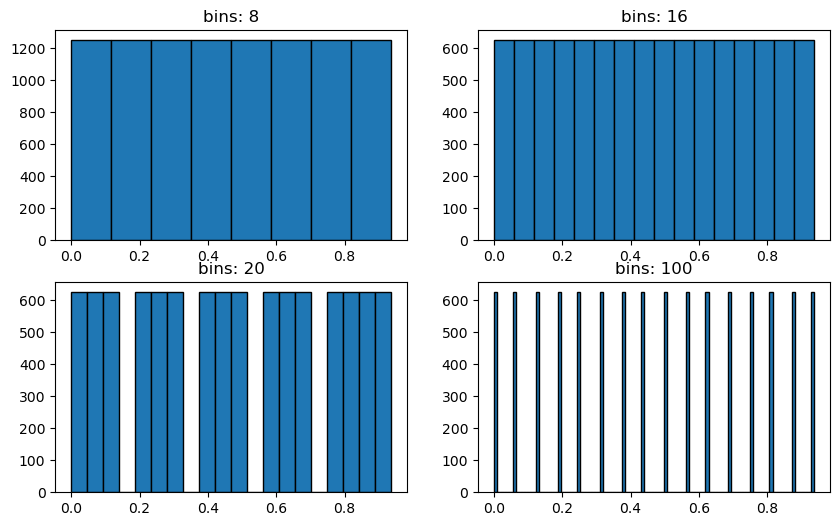

In [7]:
### Plotting
fig, axs = plt.subplots(2,2, figsize=(10,6))

#Number of bins

axs[0,0].hist(RNs, bins=8, edgecolor='black')
axs[0,0].set_title("bins: 8")

axs[0,1].hist(RNs, bins=16, edgecolor='black')
axs[0,1].set_title("bins: 16")

axs[1,0].hist(RNs, bins=20, edgecolor='black')
axs[1,0].set_title("bins: 20")

axs[1,1].hist(RNs, bins=100, edgecolor='black')
axs[1,1].set_title("bins: 100")

plt.show()

##### Scatter plots

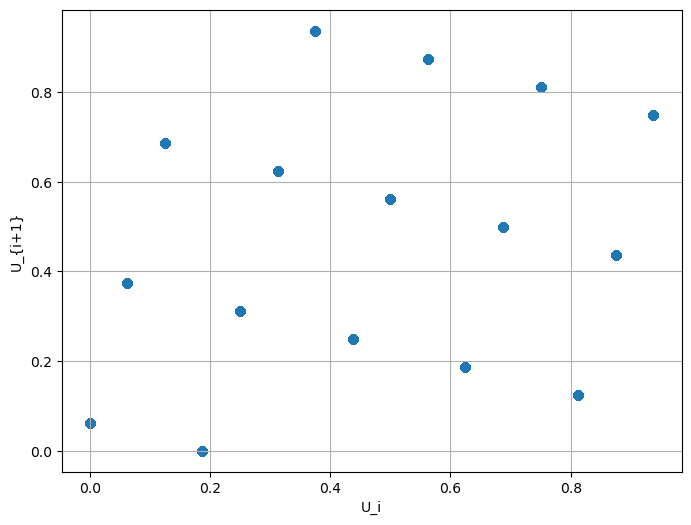

In [8]:
# Scatter plot of U_i+1 (y-axis) vs U_i (x-axis)

fig, axs = plt.subplots(1,1, figsize=(8,6))

axs.scatter(RNs[1:-2], RNs[2:-1])
axs.grid()
axs.set_xlabel('U_i')
axs.set_ylabel('U_{i+1}')

plt.show()

##### Chi squared tests

Need to bin observations in n classes, in order to use sp.chisquare()

In [9]:
###Binning random numbers

#Number of classes
n_classes = 16

#creating f_obs: observed frequency (meaning simple count) in each category
f_obs = np.histogram(RNs, bins=n_classes, range=(0,1))[0]
print('f_obs:')
print(f_obs)

print('sum of f_obs (should be n_RNs)')
print(sum(f_obs))

#Creating f_exp: expected freq. in each cat. (uniform dist.)
f_exp = np.ones(n_classes) * (n_RNs/n_classes)
print('f_exp:')
print(f_exp)
print('sum of f_exp (should be n_RNs)')
print(sum(f_exp))

# Computing chi-square test statistic and p-value
# NB: we have estimated no parameters of the expected distribution (the uniform dist.) - they  were given

T_stat, p_val = sp.stats.chisquare(f_obs, f_exp=f_exp, ddof=0, sum_check=False)

print(f"T_stat: {T_stat:.7e}")
print(f"p_val: {p_val:.10e}")
 

f_obs:
[625 625 625 625 625 625 625 625 625 625 625 625 625 625 625 625]
sum of f_obs (should be n_RNs)
10000
f_exp:
[625. 625. 625. 625. 625. 625. 625. 625. 625. 625. 625. 625. 625. 625.
 625. 625.]
sum of f_exp (should be n_RNs)
10000.0
T_stat: 0.0000000e+00
p_val: 1.0000000000e+00


##### Kolmogorov-Smirnov test

In [10]:
# Emperical distribution function
# (N.S.L, "Testing Random Numbers" June 2026, slide 19)

def F_n(x, obs):
    """
    Emperical (cumulative) distribution function ECDF
    input:
        x [np.array]:           independent variables
        obs [np.array]:         list of observations

    returns:
        [np.array]:             F_n evaluated on all x
    """

    # number of observations
    n = np.size(obs)

    #Computing F_n by number of observations smaller that x for each x
    
    # Initialising
    vals = np.zeros(np.size(x)) 
    for i in range(len(x)):
        vals[i] = (1/n) * np.sum(obs <= x[i])

    return vals

# CDF for uniform distribution
def F_uniform(x):
    """
    Cumulative distribution function for uniform distribution on x in [0,1]
    x [float]:              independent variable
    """
    return x

# The Kolmogorov-Smirnov test statistic
# (N.S.L, "Testing Random Numbers" June 2026, slide 21)

def KS_test_statistic_uniform(obs, x_grid):

    """
    KS test statistic
    obs [np.array]:         list of observations
    x_grid [np.array]:      grid to evaluate F_n and F on. Should be finer than length of obs
    """

    # Computing test statistic as sup_{x} |F_n(x) - F(x)|
    return np.max(np.abs(F_n(x_grid, obs) - F_uniform(x_grid)))

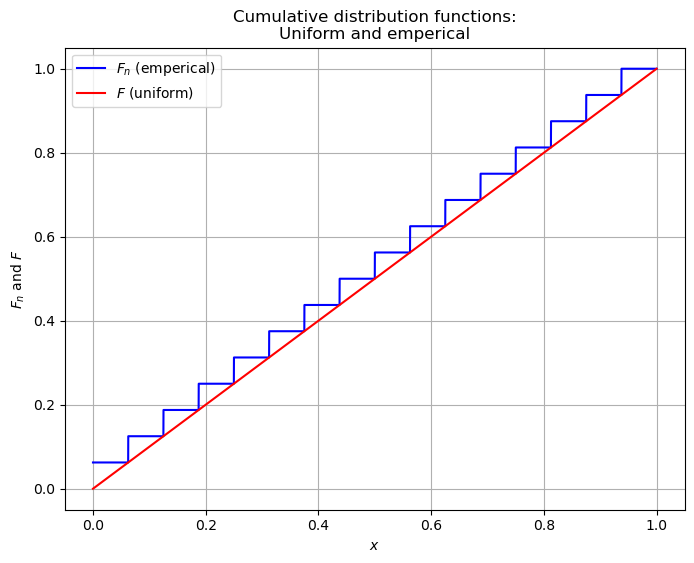

In [11]:
### Plotting the ECDF and CDF for uniform
fig, axs = plt.subplots(1,1, figsize=(8,6))

#Grid size: using number of observations
xgrid = np.linspace(0,1,num=n_RNs)

axs.plot(xgrid, F_n(xgrid, RNs), label=r'$F_n$ (emperical)', color='blue')
axs.plot(xgrid, F_uniform(xgrid), label=r'$F$ (uniform)', color='red')
axs.grid()
axs.set_xlabel(r'$x$')
axs.set_ylabel(r'$F_n$ and $F$')
axs.legend()
axs.set_title("Cumulative distribution functions:\nUniform and emperical")

plt.show()

In [12]:
from scipy.stats import kstwo, kstest

# Computing KS test statistics (non-adjusted)
D_n = KS_test_statistic_uniform(RNs, xgrid)
print(f"D_n: {D_n}")

# Computing adjusted test statistic
D_n_adj = (np.sqrt(n_RNs) + 0.12 +  0.11/np.sqrt(n_RNs))*D_n
print(f"adjusted D_n: {D_n_adj}")

# Computing the p-value form the cdf
cdf_val = sp.stats.kstwo.cdf(D_n, n_RNs)
p_val = 1-cdf_val

print(f"cdf_val: {cdf_val:.2e}")
print(f"p_val: {p_val:.2e}")


#Computing same using scipys biult in funciton

stat, p_value = kstest(RNs, 'uniform')

print('\nFrom scipy.stats.kstest')
print(f"D_n: {stat}")
print(f"p_val: {p_value:.2e}")


D_n: 0.0625
adjusted D_n: 6.25756875
cdf_val: 1.00e+00
p_val: 0.00e+00

From scipy.stats.kstest
D_n: 0.0625
p_val: 2.11e-34


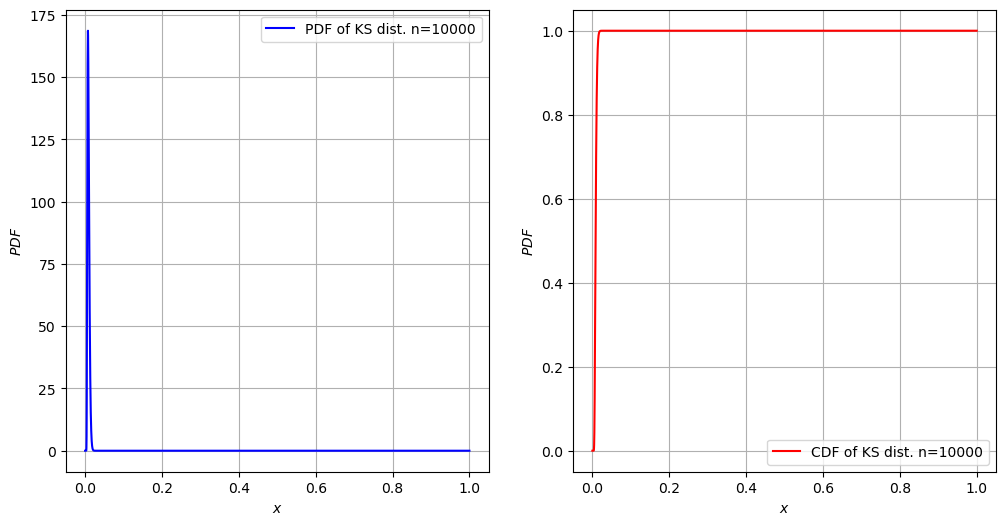

In [13]:
#Plotting the Kolmogorov distribution
fig, axs = plt.subplots(1,2, figsize=(12,6))

xgrid_plot=np.linspace(0,1, 10000)
#xgrid_plot=np.linspace(0,D_n_adj+2, 10000)

axs[0].plot(xgrid_plot, kstwo.pdf(xgrid_plot, n_RNs), label=rf'PDF of KS dist. n={n_RNs}', color='blue')
axs[0].grid()
axs[0].set_xlabel(r'$x$')
axs[0].set_ylabel(r'$PDF$')
axs[0].legend()
#axs.set_title("Cumulative distribution functions:\nUniform and emperical")

axs[1].plot(xgrid_plot, kstwo.cdf(xgrid_plot, n_RNs), label=rf'CDF of KS dist. n={n_RNs}', color='red')
axs[1].grid()
axs[1].set_xlabel(r'$x$')
axs[1].set_ylabel(r'$PDF$')
axs[1].legend()
plt.show()

##### Wald-Wolfowitz run-test


In [29]:
### Compute number of runs from median value
 
# Median
median = np.median(RNs)

# Count number above and below median
WW_n_above = np.sum(RNs > median)
WW_n_below = np.sum(RNs < median)

print("observations above median: ", WW_n_above)
print("observations belov median: ", WW_n_below)
print("sum of above and below (should be length of sequence): ", WW_n_above+WW_n_below)

# Convert sequence to binary array to detect runs: above->1, below->0
RNs_binary = np.copy(RNs)

RNs_binary[RNs < median] = 0
RNs_binary[RNs > median] = 1

# Count number of runs
runs = 1
for i in range(1,len(RNs_binary)):
    if RNs_binary[i] != RNs_binary[i-1]:
        runs += 1

print("number of runs: ", runs)

observations above median:  5000
observations belov median:  5000
sum of above and below (should be length of sequence):  10000
number of runs:  3750


In [ ]:
### Compute test statistic and p-value from normal dist



In [25]:
test1=np.array([2,3,4,5,6,7])

test2 = np.copy(test1)

test2[test1>4] = 1
test2[test1<4] = 0

print(test2)

[0 0 4 1 1 1]





(c) Repeat (a) and (b) by experimenting with different values
of “a”, “b” and “M”. In the end you should have a decent
generator. Report at least one bad and your final choice